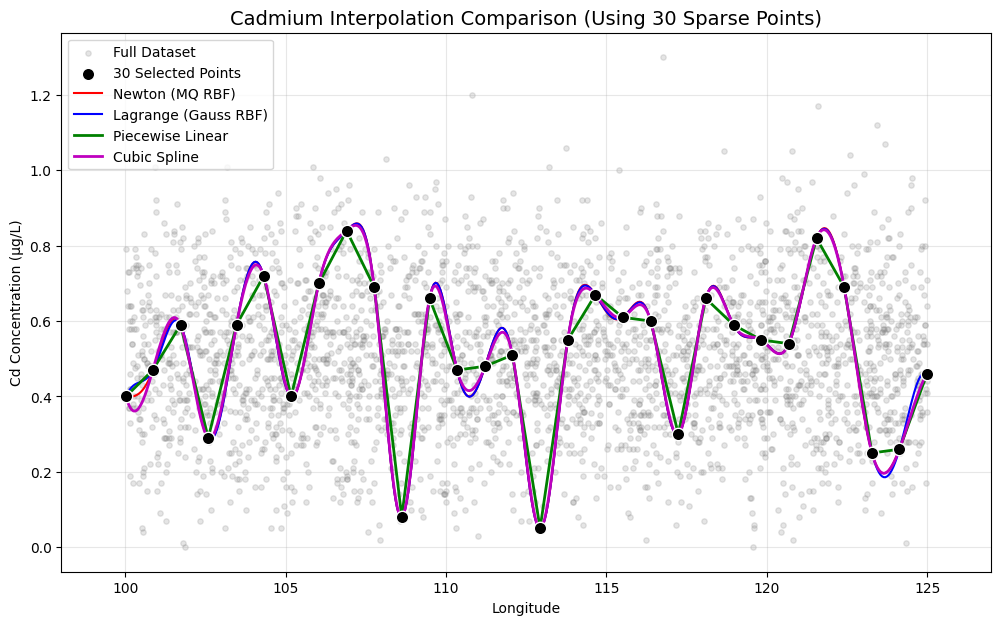

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata, Rbf
import warnings

warnings.filterwarnings('ignore')

# 1. Load and Prepare Data
# Assuming the file is in the relative path provided in your snippet
df = pd.read_csv('../output/mse_healed_data.csv')

longitude = df['Longitude'].values
latitude = df['Latitude'].values
heavy_metals_data = {
    'Hg': df['Heavy_Metals_Hg_ug_L'].values,
    'Pb': df['Heavy_Metals_Pb_ug_L'].values,
    'Cd': df['Heavy_Metals_Cd_ug_L'].values
}

# 2. Select exactly 12 representative points between Longitude 100 and 125
N_POINTS = 30
target_lons = np.linspace(100, 125, N_POINTS)

subset_indices = []
for tlon in target_lons:
    # Find index of the point closest to the target longitude
    idx = np.argmin(np.abs(longitude - tlon))
    subset_indices.append(idx)

subset_indices = np.array(subset_indices)

# Define the sparse subset (The "12 Points")
lon_sub = longitude[subset_indices]
lat_sub = latitude[subset_indices]
heavy_metals_sub = {
    metal: values[subset_indices]
    for metal, values in heavy_metals_data.items()
}

# 3. Define Interpolation Functions (Modified for 1D/2D consistency)

def newton_interpolate(x_sub, z_sub, x_grid):
    # Newton/RBF Multiquadric is robust for sparse points
    rbf = Rbf(x_sub, z_sub, function='multiquadric')
    return rbf(x_grid)

def lagrange_interpolate(x_sub, z_sub, x_grid):
    # Lagrange/RBF Gaussian
    rbf = Rbf(x_sub, z_sub, function='gaussian')
    return rbf(x_grid)

def linear_interpolate(x_sub, z_sub, x_grid):
    # Piecewise Linear
    return np.interp(x_grid, x_sub, z_sub)

def cubic_interpolate(x_sub, z_sub, x_grid):
    # Cubic Spline / 1D Griddata Cubic
    return griddata(x_sub, z_sub, x_grid, method='cubic')

# 4. Perform Interpolation and Plotting
def plot_12_point_comparison(metal_key, metal_name):
    # Create a smooth evaluation grid for the lines
    x_eval = np.linspace(100, 125, 500)
    
    # Get the 12 points for this specific metal
    z_sub = heavy_metals_sub[metal_key]
    
    # Calculate interpolations
    y_newton = newton_interpolate(lon_sub, z_sub, x_eval)
    y_lagrange = lagrange_interpolate(lon_sub, z_sub, x_eval)
    y_linear = linear_interpolate(lon_sub, z_sub, x_eval)
    
    # For cubic, we use griddata logic or simple interp1d
    from scipy.interpolate import interp1d
    f_cubic = interp1d(lon_sub, z_sub, kind='cubic', fill_value="extrapolate")
    y_cubic = f_cubic(x_eval)

    # Plotting
    plt.figure(figsize=(12, 7))
    
    # Original Data (Full set in background for context)
    plt.scatter(longitude, heavy_metals_data[metal_key], color='gray', alpha=0.2, s=15, label='Full Dataset')
    
    # The 12 Selected Points
    plt.scatter(lon_sub, z_sub, color='black', s=80, marker='o', edgecolors='white', label='30 Selected Points', zorder=5)
    
    # Interpolation Lines
    plt.plot(x_eval, y_newton, 'r-', label='Newton (MQ RBF)', linewidth=1.5)
    plt.plot(x_eval, y_lagrange, 'b-', label='Lagrange (Gauss RBF)', linewidth=1.5)
    plt.plot(x_eval, y_linear, 'g-', label='Piecewise Linear', linewidth=2)
    plt.plot(x_eval, y_cubic, 'm-', label='Cubic Spline', linewidth=2)
    
    plt.title(f'{metal_name} Interpolation Comparison (Using 30 Sparse Points)', fontsize=14)
    plt.xlabel('Longitude')
    plt.ylabel(f'{metal_key} Concentration (μg/L)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(98, 127)
    plt.show()

# Run the plot for Cadmium (Cd) as per your example image
plot_12_point_comparison('Cd', 'Cadmium')

# (Optional) Run for others
# plot_12_point_comparison('Hg', 'Mercury')
# plot_12_point_comparison('Pb', 'Lead')

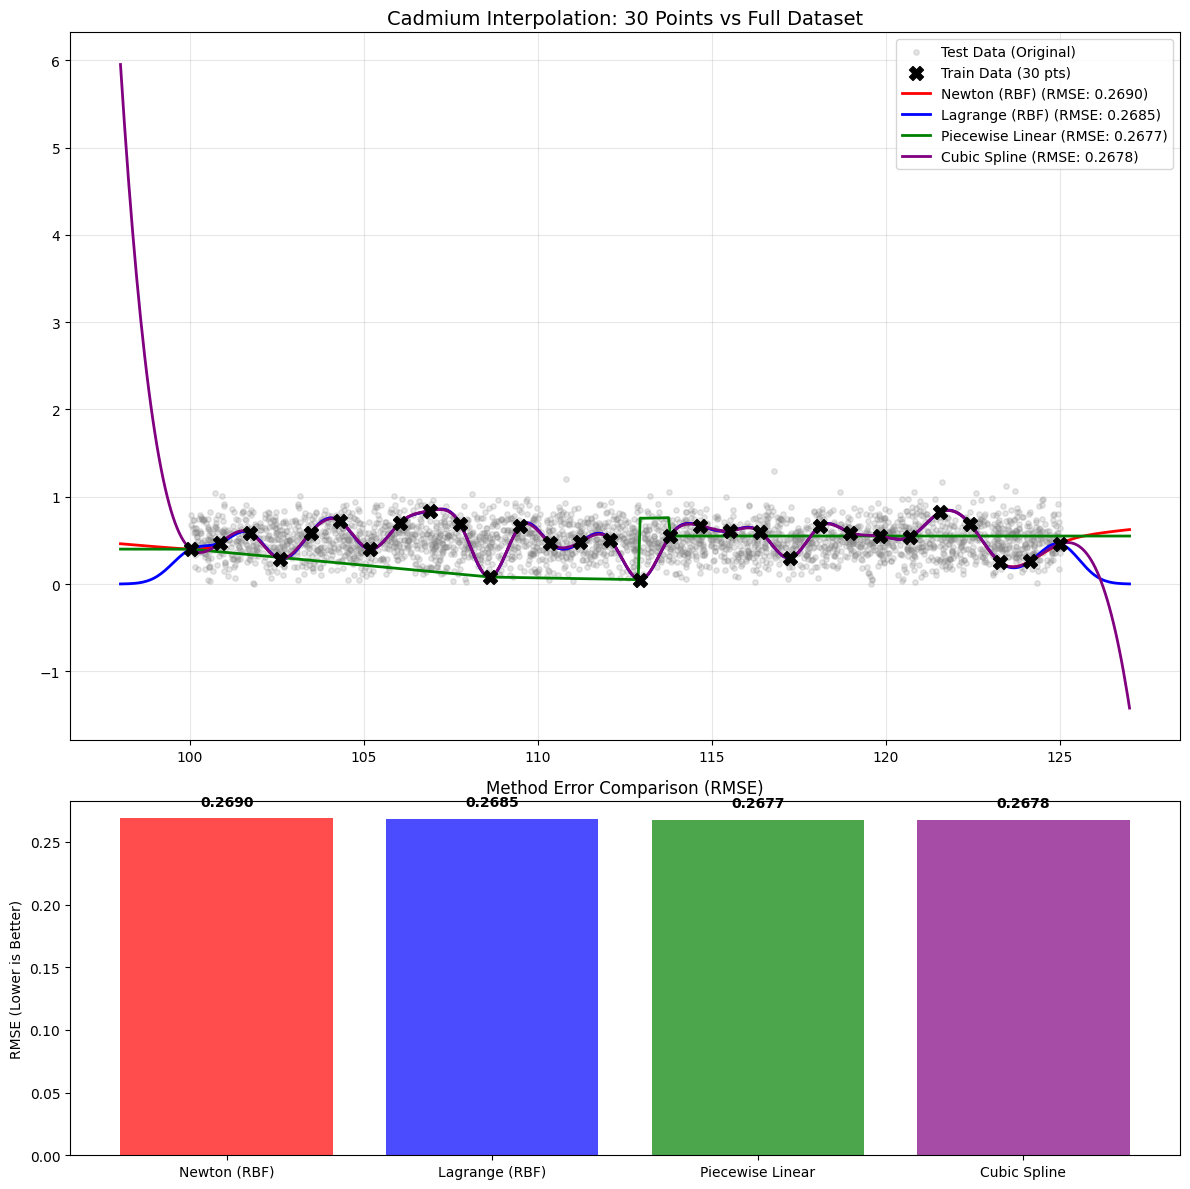


Error Summary (RMSE):
------------------------------
Newton (RBF)       : 0.26895
Lagrange (RBF)     : 0.26852
Piecewise Linear   : 0.26766
Cubic Spline       : 0.26776


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata, Rbf, interp1d
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings('ignore')

# 1. Load Data
df = pd.read_csv('../output/mse_healed_data.csv')
longitude = df['Longitude'].values
heavy_metals_data = {'Cd': df['Heavy_Metals_Cd_ug_L'].values} # Focusing on Cd

# --- CONFIGURATION ---
N_POINTS = 30  # Change this to use more/fewer points
# ---------------------

# 2. Select Subset (Training Data)
target_lons = np.linspace(100, 125, N_POINTS)
subset_indices = []
for tlon in target_lons:
    idx = np.argmin(np.abs(longitude - tlon))
    subset_indices.append(idx)

subset_indices = np.unique(subset_indices)
train_lon = longitude[subset_indices]
train_z = heavy_metals_data['Cd'][subset_indices]

# 3. Define Test Data (All points NOT in the subset)
test_mask = np.ones(len(longitude), dtype=bool)
test_mask[subset_indices] = False
test_lon = longitude[test_mask]
test_z = heavy_metals_data['Cd'][test_mask]

# 4. Interpolation & Error Calculation
methods = {
    'Newton (RBF)': lambda x: Rbf(train_lon, train_z, function='multiquadric')(x),
    'Lagrange (RBF)': lambda x: Rbf(train_lon, train_z, function='gaussian')(x),
    'Piecewise Linear': lambda x: np.interp(x, train_lon, train_z),
    'Cubic Spline': lambda x: interp1d(train_lon, train_z, kind='cubic', fill_value="extrapolate")(x)
}

errors = {}
results_plot = {}
x_eval = np.linspace(98, 127, 500)

for name, func in methods.items():
    # Predict values for the test points
    predictions = func(test_lon)
    
    # Calculate RMSE (Root Mean Square Error)
    rmse = np.sqrt(mean_squared_error(test_z, predictions))
    errors[name] = rmse
    
    # Store line for plotting
    results_plot[name] = func(x_eval)

# 5. Visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), gridspec_kw={'height_ratios': [2, 1]})

# Top Plot: Visual Comparison
ax1.scatter(test_lon, test_z, color='gray', alpha=0.2, s=15, label='Test Data (Original)')
ax1.scatter(train_lon, train_z, color='black', s=100, marker='X', label=f'Train Data ({len(train_lon)} pts)', zorder=5)

colors = ['red', 'blue', 'green', 'purple']
for (name, y_vals), color in zip(results_plot.items(), colors):
    ax1.plot(x_eval, y_vals, label=f"{name} (RMSE: {errors[name]:.4f})", color=color, linewidth=2)

ax1.set_title(f'Cadmium Interpolation: {N_POINTS} Points vs Full Dataset', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bottom Plot: Error Comparison Bar Chart
ax2.bar(errors.keys(), errors.values(), color=colors, alpha=0.7)
ax2.set_ylabel('RMSE (Lower is Better)')
ax2.set_title('Method Error Comparison (RMSE)')
for i, v in enumerate(errors.values()):
    ax2.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Print Summary Table
print("\nError Summary (RMSE):")
print("-" * 30)
for name, err in errors.items():
    print(f"{name:18} : {err:.5f}")

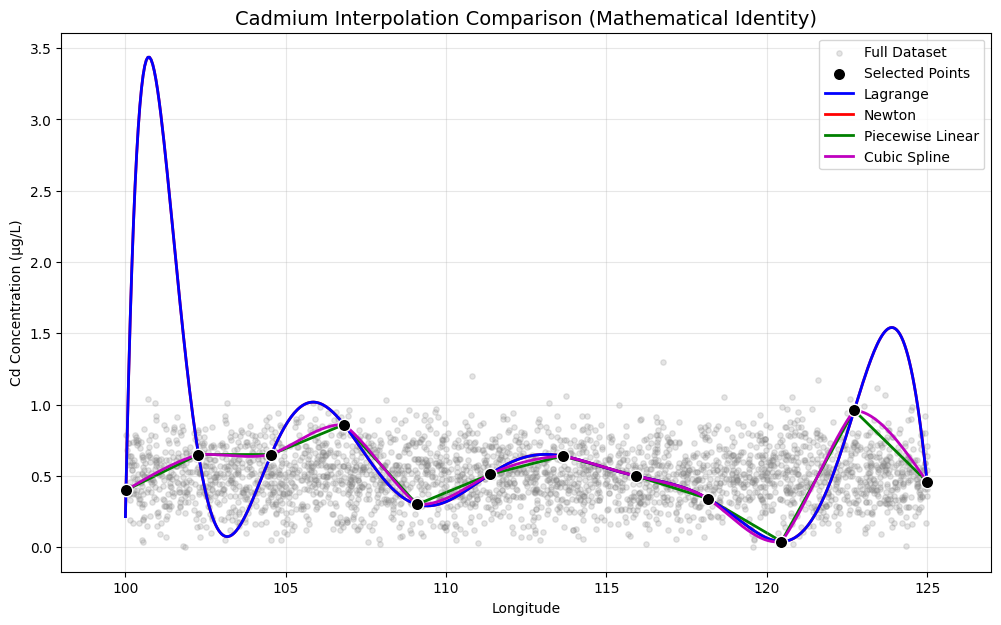

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata, Rbf
import warnings

warnings.filterwarnings('ignore')

# 1. Load and Prepare Data
# Assuming the file is in the relative path provided in your snippet
df = pd.read_csv('../output/mse_healed_data.csv')

longitude = df['Longitude'].values
latitude = df['Latitude'].values
heavy_metals_data = {
    'Hg': df['Heavy_Metals_Hg_ug_L'].values,
    'Pb': df['Heavy_Metals_Pb_ug_L'].values,
    'Cd': df['Heavy_Metals_Cd_ug_L'].values
}

# 2. Select exactly 12 representative points between Longitude 100 and 125
N_POINTS = 12
target_lons = np.linspace(100, 125, N_POINTS)

subset_indices = []
for tlon in target_lons:
    # Find index of the point closest to the target longitude
    idx = np.argmin(np.abs(longitude - tlon))
    subset_indices.append(idx)

subset_indices = np.array(subset_indices)

# Define the sparse subset (The "12 Points")
lon_sub = longitude[subset_indices]
lat_sub = latitude[subset_indices]
heavy_metals_sub = {
    metal: values[subset_indices]
    for metal, values in heavy_metals_data.items()
}

# 3. Define Interpolation Functions (Modified for 1D/2D consistency)

def lagrange_interpolate(x_sub, z_sub, x_grid):
    """
    Pure Mathematical Lagrange Interpolation:
    L(x) = sum_{j=0}^{n} y_j * product_{i=0, i!=j}^{n} (x - x_i) / (x_j - x_i)
    """
    n = len(x_sub)
    def basis_poly(j, x):
        p = 1
        for i in range(n):
            if i != j:
                p *= (x - x_sub[i]) / (x_sub[j] - x_sub[i])
        return p
    
    # Calculate the sum of y_j * L_j(x) for each x in the grid
    y_lagrange = np.zeros_like(x_grid)
    for j in range(n):
        y_lagrange += z_sub[j] * basis_poly(j, x_grid)
    return y_lagrange

def newton_interpolate(x_sub, z_sub, x_grid):
    """
    Pure Mathematical Newton Interpolation:
    Uses Divided Differences to find coefficients a_i.
    P(x) = a0 + a1(x-x0) + a2(x-x0)(x-x1) + ...
    """
    n = len(x_sub)
    # 1. Calculate Divided Difference Table
    coef = np.copy(z_sub).astype(float)
    for j in range(1, n):
        for i in range(n-1, j-1, -1):
            coef[i] = (coef[i] - coef[i-1]) / (x_sub[i] - x_sub[i-j])
            
    # 2. Evaluate the polynomial using Horner's Method for efficiency
    # This is equivalent to: a0 + a1(x-x0) + a2(x-x0)(x-x1)...
    y_newton = coef[n-1]
    for i in range(n-2, -1, -1):
        y_newton = coef[i] + (x_grid - x_sub[i]) * y_newton
    return y_newton

def linear_interpolate(x_sub, z_sub, x_grid):
    """
    Pure Mathematical Piecewise Linear:
    Finds the interval [x_i, x_{i+1}] and applies:
    y = y_i + (y_{i+1} - y_i) * (x - x_i) / (x_{i+1} - x_i)
    """
    y_linear = np.zeros_like(x_grid)
    for i in range(len(x_grid)):
        x = x_grid[i]
        # Find which "piece" of the map we are in
        idx = np.searchsorted(x_sub, x) - 1
        idx = np.clip(idx, 0, len(x_sub) - 2)
        
        # Apply the linear equation for that specific segment
        x0, x1 = x_sub[idx], x_sub[idx+1]
        y0, y1 = z_sub[idx], z_sub[idx+1]
        y_linear[i] = y0 + (y1 - y0) * (x - x0) / (x1 - x0)
    return y_linear

def cubic_interpolate(x_sub, z_sub, x_grid):
    """
    Pure Mathematical Natural Cubic Spline:
    Solves the system of equations to ensure:
    1. Continuous Value
    2. Continuous Slope
    3. Continuous Curvature
    """
    n = len(x_sub)
    h = np.diff(x_sub)
    dy = np.diff(z_sub)

    # 1. Build the Tridiagonal System (The "16 Rules" logic in 1D)
    A = np.zeros((n, n))
    B = np.zeros(n)
    
    # Natural Boundary Conditions (Curvature = 0 at ends)
    A[0, 0] = 1
    A[-1, -1] = 1
    
    for i in range(1, n - 1):
        A[i, i-1] = h[i-1]
        A[i, i] = 2 * (h[i-1] + h[i])
        A[i, i+1] = h[i]
        B[i] = 3 * (dy[i]/h[i] - dy[i-1]/h[i-1])

    # 2. Solve for second derivatives (M)
    M = np.linalg.solve(A, B)

    # 3. Evaluate the cubic polynomial for each segment
    y_cubic = np.zeros_like(x_grid)
    for i in range(len(x_grid)):
        x = x_grid[i]
        idx = np.searchsorted(x_sub, x) - 1
        idx = np.clip(idx, 0, n - 2)
        
        h_i = h[idx]
        t = (x - x_sub[idx]) / h_i
        
        # The 4-term Cubic Polynomial logic
        y_cubic[i] = ( (1-t)*z_sub[idx] + t*z_sub[idx+1] + 
                       h_i**2/6 * (( (1-t)**3 - (1-t) )*M[idx] + (t**3 - t)*M[idx+1]) )
    return y_cubic

# 4. Perform Interpolation and Plotting
# 4. Perform Interpolation and Plotting
def plot_12_point_comparison(metal_key, metal_name):
    # Create a smooth evaluation grid for the lines
    x_eval = np.linspace(100, 125, 500)
    
    # Get the points for this specific metal
    z_sub = heavy_metals_sub[metal_key]
    
    # Calculate interpolations using your custom math functions
    y_newton = newton_interpolate(lon_sub, z_sub, x_eval)
    y_lagrange = lagrange_interpolate(lon_sub, z_sub, x_eval)
    y_linear = linear_interpolate(lon_sub, z_sub, x_eval)
    y_cubic = cubic_interpolate(lon_sub, z_sub, x_eval)

    # Plotting
    plt.figure(figsize=(12, 7))
    
    # Original Data (Full set in background for context)
    plt.scatter(longitude, heavy_metals_data[metal_key], color='gray', alpha=0.2, s=15, label='Full Dataset')
    
    # The Selected Points
    plt.scatter(lon_sub, z_sub, color='black', s=80, marker='o', edgecolors='white', label='Selected Points', zorder=5)
    
    # --- Interpolation Lines ---
    
    # Lagrange is plotted with a lower zorder
    plt.plot(x_eval, y_lagrange, 'b-', label='Lagrange', linewidth=2, zorder=3)
    
    # Newton is plotted with a higher zorder to be on top
    plt.plot(x_eval, y_newton, 'r-', label='Newton', linewidth=2, zorder=2)
    
    # Piecewise and Cubic for comparison
    plt.plot(x_eval, y_linear, 'g-', label='Piecewise Linear', linewidth=2, zorder=1)
    plt.plot(x_eval, y_cubic, 'm-', label='Cubic Spline', linewidth=2, zorder=4)
    
    plt.title(f'{metal_name} Interpolation Comparison (Mathematical Identity)', fontsize=14)
    plt.xlabel('Longitude')
    plt.ylabel(f'{metal_key} Concentration (μg/L)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(98, 127)
    plt.show()

# Run for Cadmium
plot_12_point_comparison('Cd', 'Cadmium')

# (Optional) Run for others
# plot_12_point_comparison('Hg', 'Mercury')
# plot_12_point_comparison('Pb', 'Lead')

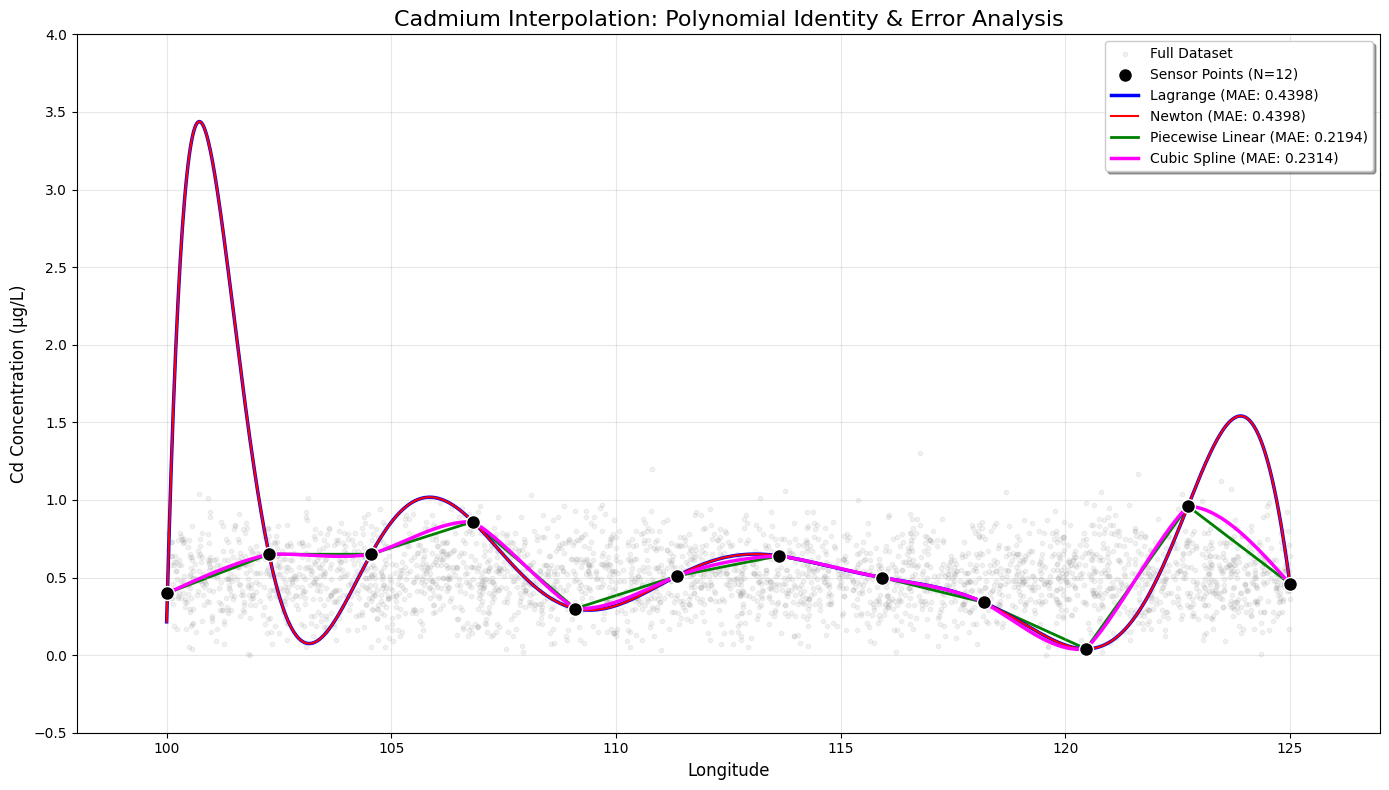

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# --- 1. LOAD AND PREPARE DATA ---
# Ensure your path is correct based on your local directory structure
df = pd.read_csv('../output/mse_healed_data.csv')

longitude = df['Longitude'].values
latitude = df['Latitude'].values
heavy_metals_data = {
    'Hg': df['Heavy_Metals_Hg_ug_L'].values,
    'Pb': df['Heavy_Metals_Pb_ug_L'].values,
    'Cd': df['Heavy_Metals_Cd_ug_L'].values
}

# Select 12 representative points for the sparse model
N_POINTS = 12
target_lons = np.linspace(100, 125, N_POINTS)

subset_indices = []
for tlon in target_lons:
    idx = np.argmin(np.abs(longitude - tlon))
    subset_indices.append(idx)

subset_indices = np.array(subset_indices)

# Define the sparse subset
lon_sub = longitude[subset_indices]
lat_sub = latitude[subset_indices]
heavy_metals_sub = {
    metal: values[subset_indices]
    for metal, values in heavy_metals_data.items()
}

# --- 2. MATHEMATICAL INTERPOLATION FUNCTIONS ---

def lagrange_interpolate(x_sub, z_sub, x_grid):
    """Pure Mathematical Lagrange: L(x) = sum(y_j * Product((x-xi)/(xj-xi)))"""
    n = len(x_sub)
    def basis_poly(j, x):
        p = 1
        for i in range(n):
            if i != j:
                p *= (x - x_sub[i]) / (x_sub[j] - x_sub[i])
        return p
    
    y_lagrange = np.zeros_like(x_grid)
    for j in range(n):
        y_lagrange += z_sub[j] * basis_poly(j, x_grid)
    return y_lagrange

def newton_interpolate(x_sub, z_sub, x_grid):
    """Pure Mathematical Newton: Divided Differences + Horner's Method"""
    n = len(x_sub)
    coef = np.copy(z_sub).astype(float)
    for j in range(1, n):
        for i in range(n-1, j-1, -1):
            coef[i] = (coef[i] - coef[i-1]) / (x_sub[i] - x_sub[i-j])
            
    y_newton = coef[n-1]
    for i in range(n-2, -1, -1):
        y_newton = coef[i] + (x_grid - x_sub[i]) * y_newton
    return y_newton

def linear_interpolate(x_sub, z_sub, x_grid):
    """Piecewise Linear: Straight-line connection between neighbors"""
    y_linear = np.zeros_like(x_grid)
    for i in range(len(x_grid)):
        x = x_grid[i]
        idx = np.searchsorted(x_sub, x) - 1
        idx = np.clip(idx, 0, len(x_sub) - 2)
        x0, x1 = x_sub[idx], x_sub[idx+1]
        y0, y1 = z_sub[idx], z_sub[idx+1]
        y_linear[i] = y0 + (y1 - y0) * (x - x0) / (x1 - x0)
    return y_linear

def cubic_interpolate(x_sub, z_sub, x_grid):
    """Natural Cubic Spline: Tridiagonal Matrix Solver for C2 Continuity"""
    n = len(x_sub)
    h = np.diff(x_sub)
    dy = np.diff(z_sub)

    A = np.zeros((n, n))
    B = np.zeros(n)
    A[0, 0] = 1
    A[-1, -1] = 1
    
    for i in range(1, n - 1):
        A[i, i-1] = h[i-1]
        A[i, i] = 2 * (h[i-1] + h[i])
        A[i, i+1] = h[i]
        B[i] = 3 * (dy[i]/h[i] - dy[i-1]/h[i-1])

    M = np.linalg.solve(A, B)

    y_cubic = np.zeros_like(x_grid)
    for i in range(len(x_grid)):
        x = x_grid[i]
        idx = np.searchsorted(x_sub, x) - 1
        idx = np.clip(idx, 0, n - 2)
        h_i = h[idx]
        t = (x - x_sub[idx]) / h_i
        y_cubic[i] = ( (1-t)*z_sub[idx] + t*z_sub[idx+1] + 
                       h_i**2/6 * (( (1-t)**3 - (1-t) )*M[idx] + (t**3 - t)*M[idx+1]) )
    return y_cubic

# --- 3. ERROR CALCULATION LOGIC ---

def calculate_mae(x_full, y_full, x_sub, y_sub, interpolate_func):
    """Calculates Mean Absolute Error across the entire dataset"""
    # Generate predictions for all original longitudes
    y_pred = interpolate_func(x_sub, y_sub, x_full)
    # Mask out the points we used for training (error is 0 there)
    mask = ~np.isin(x_full, x_sub)
    return np.mean(np.abs(y_full[mask] - y_pred[mask]))

# --- 4. PLOTTING AND COMPARISON ---

def plot_comparison(metal_key, metal_name):
    x_eval = np.linspace(100, 125, 1000)
    z_sub = heavy_metals_sub[metal_key]
    y_full = heavy_metals_data[metal_key]
    
    # Run Interpolations
    y_newton = newton_interpolate(lon_sub, z_sub, x_eval)
    y_lagrange = lagrange_interpolate(lon_sub, z_sub, x_eval)
    y_linear = linear_interpolate(lon_sub, z_sub, x_eval)
    y_cubic = cubic_interpolate(lon_sub, z_sub, x_eval)

    # Calculate MAEs
    mae_newton = calculate_mae(longitude, y_full, lon_sub, z_sub, newton_interpolate)
    mae_lagrange = calculate_mae(longitude, y_full, lon_sub, z_sub, lagrange_interpolate)
    mae_linear = calculate_mae(longitude, y_full, lon_sub, z_sub, linear_interpolate)
    mae_cubic = calculate_mae(longitude, y_full, lon_sub, z_sub, cubic_interpolate)

    plt.figure(figsize=(14, 8))
    
    # Context data
    plt.scatter(longitude, y_full, color='gray', alpha=0.1, s=10, label='Full Dataset')
    plt.scatter(lon_sub, z_sub, color='black', s=100, edgecolors='white', zorder=10, label='Sensor Points (N=12)')
    
    # Plotting with zorder and MAE display
    # Lagrange behind Newton
    plt.plot(x_eval, y_lagrange, color='blue', linewidth=2.5, zorder=2, 
             label=f'Lagrange (MAE: {mae_lagrange:.4f})')
    
    # Newton on top of Lagrange
    plt.plot(x_eval, y_newton, color='red', linewidth=1.5, linestyle='-', zorder=3, 
             label=f'Newton (MAE: {mae_newton:.4f})')
    
    plt.plot(x_eval, y_linear, color='green', linewidth=2, zorder=1, 
             label=f'Piecewise Linear (MAE: {mae_linear:.4f})')
    
    plt.plot(x_eval, y_cubic, color='magenta', linewidth=2.5, zorder=4, 
             label=f'Cubic Spline (MAE: {mae_cubic:.4f})')

    plt.title(f'{metal_name} Interpolation: Polynomial Identity & Error Analysis', fontsize=16)
    plt.xlabel('Longitude', fontsize=12)
    plt.ylabel(f'{metal_key} Concentration (μg/L)', fontsize=12)
    
    # Legend settings
    plt.legend(loc='upper right', frameon=True, shadow=True)
    plt.grid(True, alpha=0.3)
    plt.xlim(98, 127)
    plt.ylim(-0.5, 4.0) # Adjusted to show Runge phenomenon spikes
    
    plt.tight_layout()
    plt.show()

# Execution
plot_comparison('Cd', 'Cadmium')